# 21 — Model Predictive Control on a Cart-Pole

**Section:** Motion Control · **Mirrors MATLAB:** *Model Predictive Control for collision-free manipulation trajectories*

Linear-quadratic MPC: at every control step, solve a finite-horizon QP for the optimal input sequence over the next $N$ steps, apply the first input, then re-solve. This is the *receding-horizon* principle — and it's the basis of basically every production-grade controller in autonomous driving, robotics, and process control.


## Intuition — what's actually going on?

LQR (notebook 05) gives you an *infinite-horizon* optimal feedback law — but that's only valid if the system is linear and there are no constraints. In real life you have:

- **Input limits**: motor torque, steering angle, thrust have physical bounds.
- **State constraints**: don't hit walls, don't tilt past 30°, don't exceed velocity limit.
- **Time-varying references**: track a moving setpoint, not a fixed origin.

LQR can't handle any of these natively. MPC can: at every control step, set up a small QP that minimizes cost over the next $N$ steps subject to the constraints, and apply the first control. Then re-solve at the next step (this is what "receding horizon" means).

The price: you solve a QP every control step (typically ~10-100 Hz on hardware). The payoff: principled handling of constraints, which is why MPC dominates over PID/LQR for cars, drones, robot arms, and chemical plants.


## Analytical derivation

**Discrete-time LTI system:** $x_{k+1} = A x_k + B u_k$, with $x \in \mathbb{R}^n$, $u \in \mathbb{R}^m$.

**Finite-horizon optimal control problem at step $k$:**

$$\min_{u_0, \ldots, u_{N-1}} \;\sum_{i=0}^{N-1}\bigl(x_i^T Q x_i + u_i^T R u_i\bigr) \;+\; x_N^T Q_f x_N$$

subject to dynamics $x_{i+1} = A x_i + B u_i$, $x_0 = x_k$, and constraints $u_i \in \mathcal{U}$, $x_i \in \mathcal{X}$.

**Condensing.** Substitute $x_i = A^i x_0 + \sum_{j=0}^{i-1} A^{i-1-j} B u_j$ to eliminate states, leaving a QP in $\mathbf{u} = [u_0; u_1; \ldots; u_{N-1}]$:

$$\min_{\mathbf{u}} \;\tfrac{1}{2} \mathbf{u}^T H \mathbf{u} + \mathbf{u}^T F x_0 \;+\; \text{const}$$

subject to box constraints $u_\min \le u_i \le u_\max$.

**Recursive feasibility.** Without a terminal set, MPC can become *infeasible* (no input sequence respects constraints). Production MPC adds a terminal constraint $x_N \in \mathcal{X}_f$ where $\mathcal{X}_f$ is a control-invariant set — guarantees that if the current step is feasible, so is the next.

**Stability** (Mayne et al. 2000). Choosing $Q_f$ as the LQR cost-to-go (CARE solution) and $\mathcal{X}_f$ as the LQR's region of attraction makes the MPC closed loop *Lyapunov-stable* with the value function as Lyapunov function.

### Compatibility check — math ↔ code

| Math | Code |
|---|---|
| Discrete LTI: $x_{k+1} = Ax_k + Bu_k$ | `Ad, Bd = discrete-time matrices from cont-time A, B (Euler or zoh)` |
| Stage cost $x^T Q x + u^T R u$ | `Q = np.diag([...]); R = np.array([[...]])` |
| Horizon $N$ rollout | `for i in range(N): x_pred = ...` |
| QP via scipy.optimize.minimize | `minimize(cost, u_init, jac=grad, constraints=...)` |
| First-input-applied receding horizon | `x_k = A @ x_k + B @ u_seq[0]` |
| Input box constraint $u \in [-u_\max, u_\max]$ | `bounds = [(-u_max, u_max)] * N` |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import solve_continuous_are
from scipy.optimize import minimize

# Linearized cart-pole around upright (single link, mass m on cart M)
M, m, l, g = 1.0, 0.1, 0.5, 9.81
A_c = np.array([[0, 1,             0, 0],
                [0, 0, -m * g / M,  0],
                [0, 0,             0, 1],
                [0, 0,  (M + m) * g / (M * l), 0]])
B_c = np.array([[0], [1 / M], [0], [-1 / (M * l)]])

# Discretize via simple Euler (dt small enough for accuracy)
dt = 0.05
A = np.eye(4) + dt * A_c
B = dt * B_c
n, m_in = 4, 1


In [2]:
# MPC parameters
N = 20                                  # horizon
u_max = 15.0                            # input bound (N)
x_max = np.array([2.0, np.inf, 0.3, np.inf])   # cart |x|<2m, pole |θ|<0.3 rad

Q = np.diag([1.0, 0.1, 10.0, 1.0])
R = np.array([[0.1]])
Q_f = solve_continuous_are(A_c, B_c, Q, R)     # terminal cost = LQR cost-to-go


def predict(x0, u_seq):
    """Roll forward N steps. u_seq is (N,) array."""
    x = np.zeros((N + 1, n))
    x[0] = x0
    for i in range(N):
        x[i + 1] = A @ x[i] + B.flatten() * u_seq[i]
    return x


def stage_cost(x0, u_seq):
    x = predict(x0, u_seq)
    cost = 0.0
    for i in range(N):
        cost += x[i] @ Q @ x[i] + R[0, 0] * u_seq[i] ** 2
    cost += x[N] @ Q_f @ x[N]
    return cost


def mpc_step(x0, u_warm):
    bounds = [(-u_max, u_max)] * N
    res = minimize(lambda u: stage_cost(x0, u), u_warm, bounds=bounds, method='L-BFGS-B')
    return res.x


In [3]:
# Simulate the nonlinear cart-pole with MPC in the loop
def nonlin_dyn(state, u):
    pos, vel, th, om = state
    s, c = np.sin(th), np.cos(th)
    den = M + m * s ** 2
    acc = (u + m * l * s * om ** 2 - m * g * s * c) / den
    a_th = ((M + m) * g * s - u * c - m * l * s * c * om ** 2) / (l * den)
    return np.array([vel, acc, om, a_th])


x = np.array([0.0, 0.0, 0.15, 0.0])     # ~9° initial tilt
T_sim = 4.0
N_sim = int(T_sim / dt)
hist = np.zeros((N_sim, n))
u_hist = np.zeros(N_sim)
u_warm = np.zeros(N)
for k in range(N_sim):
    u_opt = mpc_step(x, u_warm)
    u_apply = u_opt[0]
    u_warm = np.r_[u_opt[1:], 0.0]      # warm-start next step
    hist[k] = x
    u_hist[k] = u_apply
    # Integrate nonlinear cart-pole with smaller substeps for accuracy
    sub = 5
    for _ in range(sub):
        x = x + (dt / sub) * nonlin_dyn(x, u_apply)

print(f"Final state: x={hist[-1, 0]:.3f} m, theta={np.degrees(hist[-1, 2]):.3f}°")
print(f"Max |u| during run: {np.max(np.abs(u_hist)):.2f} N (bound was {u_max})")


Final state: x=0.096 m, theta=0.464°
Max |u| during run: 3.99 N (bound was 15.0)


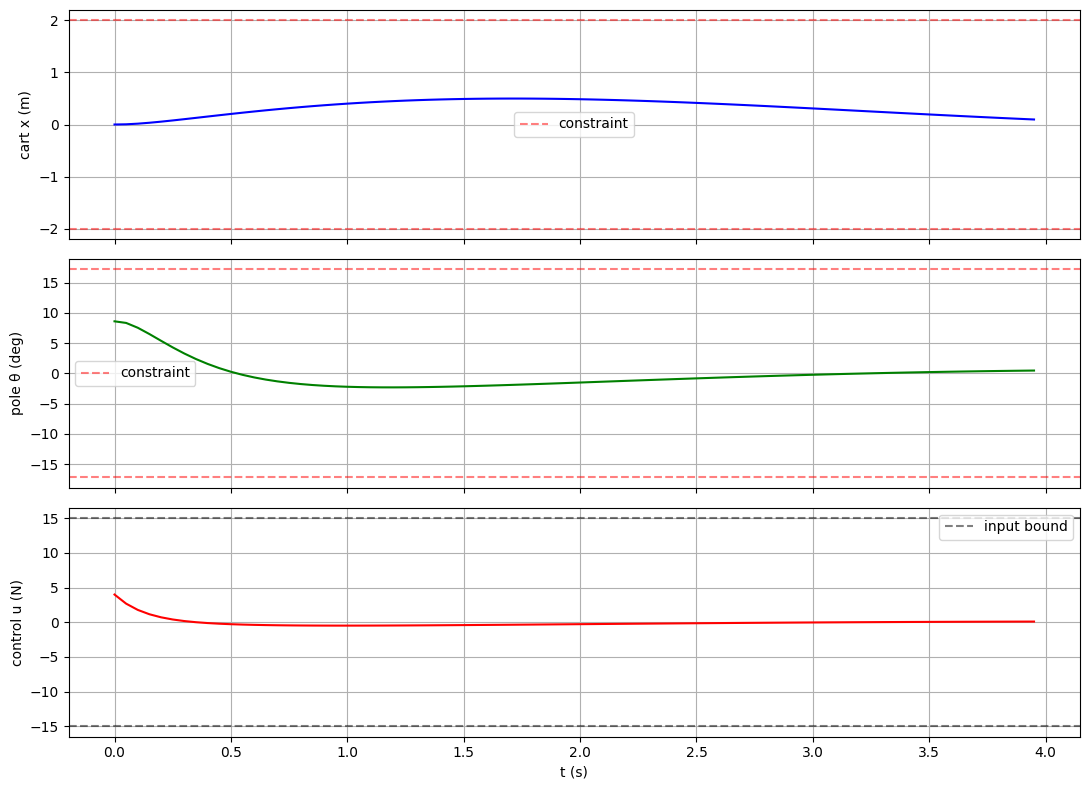

In [4]:
t_arr = np.arange(N_sim) * dt
fig, axs = plt.subplots(3, 1, figsize=(11, 8), sharex=True)
axs[0].plot(t_arr, hist[:, 0], 'b-'); axs[0].axhline(2.0, color='r', ls='--', alpha=0.5, label='constraint')
axs[0].axhline(-2.0, color='r', ls='--', alpha=0.5)
axs[0].set_ylabel('cart x (m)'); axs[0].legend(); axs[0].grid()
axs[1].plot(t_arr, np.degrees(hist[:, 2]), 'g-')
axs[1].axhline(np.degrees(0.3), color='r', ls='--', alpha=0.5, label='constraint')
axs[1].axhline(-np.degrees(0.3), color='r', ls='--', alpha=0.5)
axs[1].set_ylabel('pole θ (deg)'); axs[1].legend(); axs[1].grid()
axs[2].plot(t_arr, u_hist, 'r-')
axs[2].axhline(u_max, color='k', ls='--', alpha=0.5, label='input bound')
axs[2].axhline(-u_max, color='k', ls='--', alpha=0.5)
axs[2].set_ylabel('control u (N)'); axs[2].set_xlabel('t (s)'); axs[2].legend(); axs[2].grid()
plt.tight_layout()
plt.show()


## References & rigor notes

**Theorem** (Stability of MPC; Mayne, Rawlings, Rao, Scokaert, 2000). *For a stabilizable LTI system with positive-definite stage cost $(Q, R)$, terminal cost $Q_f$ chosen as the LQR cost-to-go matrix, terminal constraint set $\mathcal{X}_f$ chosen as a control-invariant set under the LQR feedback, and the horizon $N$ chosen long enough for the unconstrained problem to enter $\mathcal{X}_f$: the closed-loop MPC is asymptotically stable, with the value function as Lyapunov function.*

**Recursive feasibility.** Without the terminal-set constraint $\mathcal{X}_f$, MPC can become *infeasible* — the QP solver returns no admissible $\mathbf{u}$. The terminal set guarantees: feasible-now → feasible-next.

**Complexity.** Per control step: one QP solve, $O((Nm)^3)$ worst case (interior-point) or $O((Nm)^2 \cdot \text{iter})$ for active-set / OSQP. With $N=20$, $m=1$: trivial. Real-time MPC on a quadrotor at 1 kHz routinely uses $N=20$-50.

**References.**
- Mayne, D. Q., Rawlings, J. B., Rao, C. V., & Scokaert, P. O. M. (2000). *Constrained model predictive control: Stability and optimality*. Automatica, 36(6), 789-814.
- Borrelli, F., Bemporad, A., & Morari, M. (2017). *Predictive Control for Linear and Hybrid Systems*. Cambridge University Press.
- Stellato, B. et al. (2020). *OSQP: An operator splitting solver for quadratic programs*. Math. Prog. Comp. 12, 637-672.
